## Exploratory Data Analysis – EDA

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from config.paths import CLEANED_HOTEL_FILE

df = pd.read_csv(CLEANED_HOTEL_FILE)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,14,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240,0,Transient,98.0,0,1,Check-Out,2015-07-03,2
3,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240,0,Transient,98.0,0,1,Check-Out,2015-07-03,2
4,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,14,0,Transient,107.0,0,0,Check-Out,2015-07-03,2


### 1. Overview ADR rate distribution
- ADR between 50 - 150

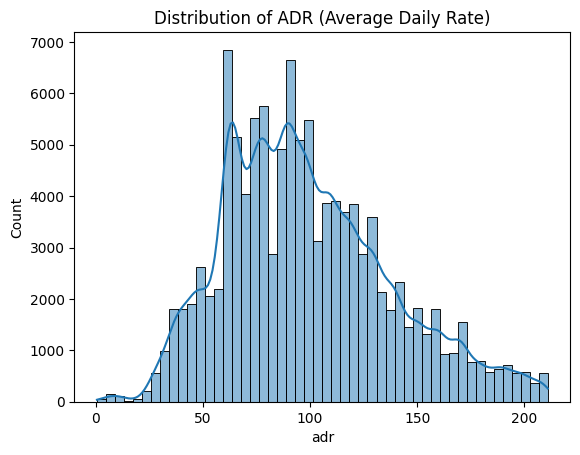

In [19]:
# Distribution of ADR
sns.histplot(df['adr'], bins=50, kde=True)
plt.title("Distribution of ADR (Average Daily Rate)")
plt.show()

### 2. ADR by Hotel type
- **City Hotel has significantly higher ADR than Resort Hotel**
    - City Hotel average ADR: ~100-120 EUR
    - Resort Hotel average ADR: ~80-100 EUR
- **Hotel Characteristics:**
    - **City Hotel:**
        - Wider ADR distribution
        - More high-value outliers
        - Higher overall price range
    - **Resort Hotel:**
        - Narrower ADR distribution
        - More stable, lower prices
        - Fewer outliers

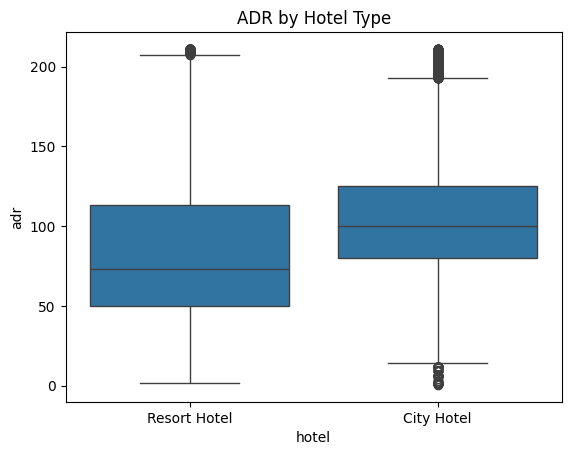

In [22]:
sns.boxplot(x='hotel', y='adr', data=df)
plt.title("ADR by Hotel Type")
plt.show()

### 3. Booking and Demand Analysis
- **Seasonal Trends:**
    - **High Season:** Months 6-8 (Jun-Aug) - Peak ADR ~110-120 EUR
    - **Low Season:** Months 1, 11-12 (Jan, Nov-Dec) - Lowest ADR ~80-90 EUR
- **Hotel Characteristics:**
    - Gradual ADR increase from Month 2 onward
    - Summer peak (Jun-Aug)
    - Sharp decline after Month 8
    - Year-end/beginning year lowest points

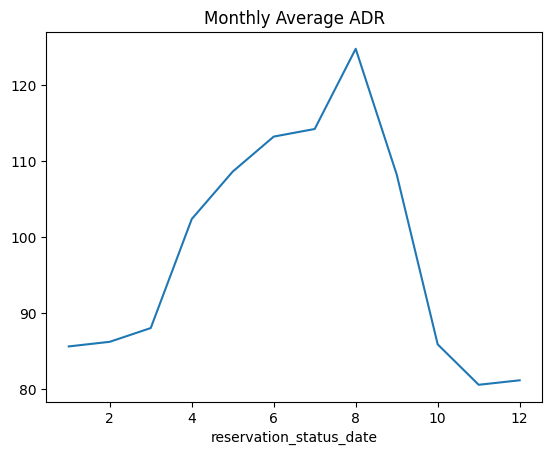

In [23]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df.groupby(df['reservation_status_date'].dt.month)['adr'].mean().plot(kind='line')
plt.title("Monthly Average ADR")
plt.show()